# GOES-18 ABI CONUS — one band, full sector then a domain

The CONUS sector of GOES-18 covers the western United States. It does **not** reach Alaska, so a Shishaldin box cannot be cropped from it.

Everything is in this notebook: where the files come from, the domain,
and the whole plotting code. Change any of it and re-run — nothing is hidden in
a library.

**Steps:** point at your folder → plot the complete scan → set your domain →
plot that domain.


## Setup

In [1]:
import glob
import math
import warnings

import yaml
from pathlib import Path

import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from pyresample import create_area_def
from satpy import Scene
from satpy.enhancements.enhancer import get_enhanced_image
from shapely.geometry import box

warnings.filterwarnings("ignore")


In [2]:
# ---------------------------------------------------------------
# Helper kept in the notebook so you can change it: coastline segments
# clipped to a lon/lat box. Change "10m" to "50m" for a coarser, faster line.
# ---------------------------------------------------------------
def coastlines(bbox, resolution="10m"):
    west, south, east, north = bbox[0], bbox[1], bbox[2], bbox[3]
    clip = box(west, south, east, north)
    segments = []
    feature = cfeature.NaturalEarthFeature("physical", "coastline", resolution)
    for geometry in feature.intersecting_geometries([west, east, south, north]):
        piece = geometry.intersection(clip)
        for line in (piece.geoms if hasattr(piece, "geoms") else [piece]):
            if not line.is_empty and line.length > 0:
                x, y = line.xy
                segments.append((np.asarray(x), np.asarray(y)))
    return segments


def lon_label(value, _pos=None):
    v = ((value + 180) % 360) - 180
    return f"{abs(v):g}\u00b0{'E' if v >= 0 else 'W'}"


def lat_label(value, _pos=None):
    return f"{abs(value):g}\u00b0{'N' if value >= 0 else 'S'}"


In [3]:
# ---------------------------------------------------------------
# CONFIGURATION -- everything comes from config.yml at the repository root.
# Edit that file, or override any value in the next few lines.
# ---------------------------------------------------------------
CONFIG = yaml.safe_load(open("../config.yml"))

style = CONFIG["style"]
COAST_COLOUR = style["coast_colour"]
COAST_WIDTH = style["coast_width"]
COAST_RES = style["coast_resolution"]

GRID_COLOUR = style["grid_colour"]
GRID_ALPHA = style["grid_alpha"]
GRID_STYLE = style["grid_style"]
GRID_WIDTH = style["grid_width"]

MARKER_LON = style["marker_lon"]      # set to None to hide the marker
MARKER_LAT = style["marker_lat"]
MARKER_COLOUR = style["marker_colour"]
MARKER_SIZE = style["marker_size"]

FIG_WIDTH = style["figure_width"]
DPI = style["dpi"]
RESOLUTION = style["resolution"]
TARGET_PIXELS = style["overview_pixels"]

print("style loaded from config.yml:", ", ".join(sorted(style)))


style loaded from config.yml: coast_colour, coast_resolution, coast_width, dpi, figure_width, flash_colour, flash_edge_width, flash_size, grid_alpha, grid_colour, grid_style, grid_width, marker_colour, marker_lat, marker_lon, marker_size, overview_pixels, resolution


## 1. Your files

In [4]:
# ---------------------------------------------------------------
# 1. YOUR FILES  -- point this at the folder where your files are
# ---------------------------------------------------------------
DATA_DIR = Path("..") / CONFIG["data"]["conus"]

files = sorted(glob.glob(str(DATA_DIR / "*.nc")))
print(f"folder: {DATA_DIR}")
print(f"{len(files)} file(s) found:")
for name in files:
    print("   ", Path(name).name)

# If the folder is empty, this fetches the example scan so the notebook can
# run. Delete this block once you use your own files.
if not files:
    import sys
    sys.path.insert(0, "..")
    from examples.glm import abi_scan_keys, download_abi
    from datetime import datetime
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    moment = datetime.fromisoformat(CONFIG["scene"]["conus_time"])
    bucket = CONFIG["scene"]["bucket"]
    keys = abi_scan_keys(bucket, "ABI-L1b-RadC", moment, ("C13",))
    files = sorted(download_abi(bucket, keys, DATA_DIR))
    print(f"downloaded {len(files)} file(s)")

# Files must all come from the SAME scan.


folder: ../data/conus
1 file(s) found:
    OR_ABI-L1b-RadC-M6C13_G18_s20232761901171_e20232761903556_c20232761904010.nc


## 2. Load the band

In [5]:
product = CONFIG["products"]["band"]
BAND = product["band"]
CMAP = product["cmap"]
VMIN, VMAX = product["vmin"], product["vmax"]
COLOURBAR_LABEL = product["colorbar_label"]
TITLE = f"{BAND} 10.3 um"

OUT_FULL = Path("../output/conus_full.png")
OUT_DOMAIN = Path("../output/conus_domain.png")
OUT_FULL.parent.mkdir(parents=True, exist_ok=True)

scene = Scene(reader="abi_l1b", filenames=files)
scene.load([BAND])
print("loaded", BAND, scene[BAND].shape)


loaded C13 (1500, 2500)


## 3. The complete scan

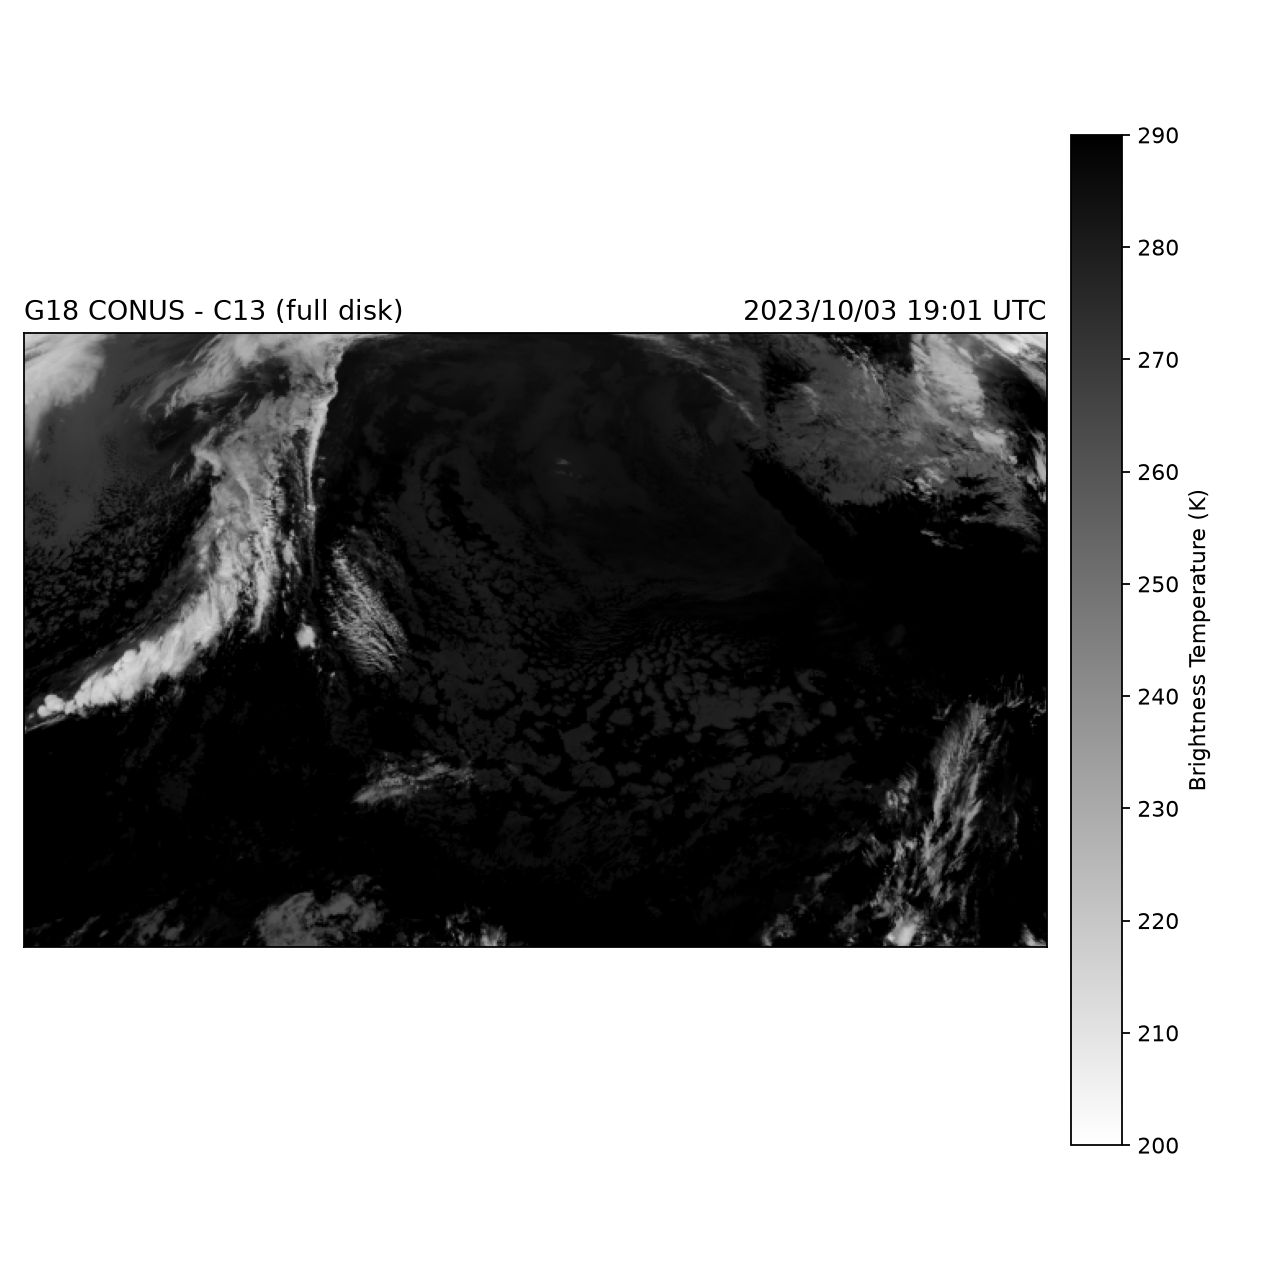

In [6]:
# ---------------------------------------------------------------
# 3. PLOT THE COMPLETE SCAN
# Shown in the satellite's own geometry, with no lon/lat graticule.
# Reason: GOES-West products reach the antimeridian, so a single
# (min_lon .. max_lon) range cannot describe them -- forcing one squashes the
# image across the whole globe. The lon/lat map, with coastlines, graticule and
# coordinates, starts at the domain step below.
# ---------------------------------------------------------------
area = scene[BAND].attrs["area"]
step = 2 ** max(0, math.ceil(math.log2(max(area.width, area.height) / TARGET_PIXELS)))
small = scene.resample(area.aggregate(x=step, y=step), resampler="native")
values = small[BAND].values

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(values, origin="upper", cmap=CMAP, vmin=VMIN, vmax=VMAX)
ax.set_title("G18 CONUS - " + BAND + " (full disk)", loc="left")
ax.set_title(f"{small[BAND].attrs['start_time']:%Y/%m/%d %H:%M} UTC", loc="right")
ax.set_xticks([]); ax.set_yticks([])
cb = fig.colorbar(im, ax=ax, pad=0.02, shrink=0.82)
cb.set_label(COLOURBAR_LABEL)
fig.tight_layout()
fig.savefig(OUT_FULL, dpi=DPI)
plt.close(fig)
display(Image(filename=str(OUT_FULL)))


## 4. Your domain

Write the four numbers yourself: `(min_lon, min_lat, max_lon, max_lat)` in
decimal degrees. The box must fall inside what this product actually observes.


In [7]:
# YOUR DOMAIN -- write the four numbers yourself, in decimal degrees.
# There is no preset: this is the area you choose to look at.
#
#     DOMAIN = (min_lon, min_lat, max_lon, max_lat)
#
# Set DOMAIN = None to skip the crop and plot the complete image instead.
# The box must fall inside what this product actually observes.

DOMAIN = (-125.0, 32.0, -115.0, 42.0)

print("domain:", DOMAIN, " resolution:", RESOLUTION)


domain: (-125.0, 32.0, -115.0, 42.0)  resolution: 0.02


## 5. Plot your domain

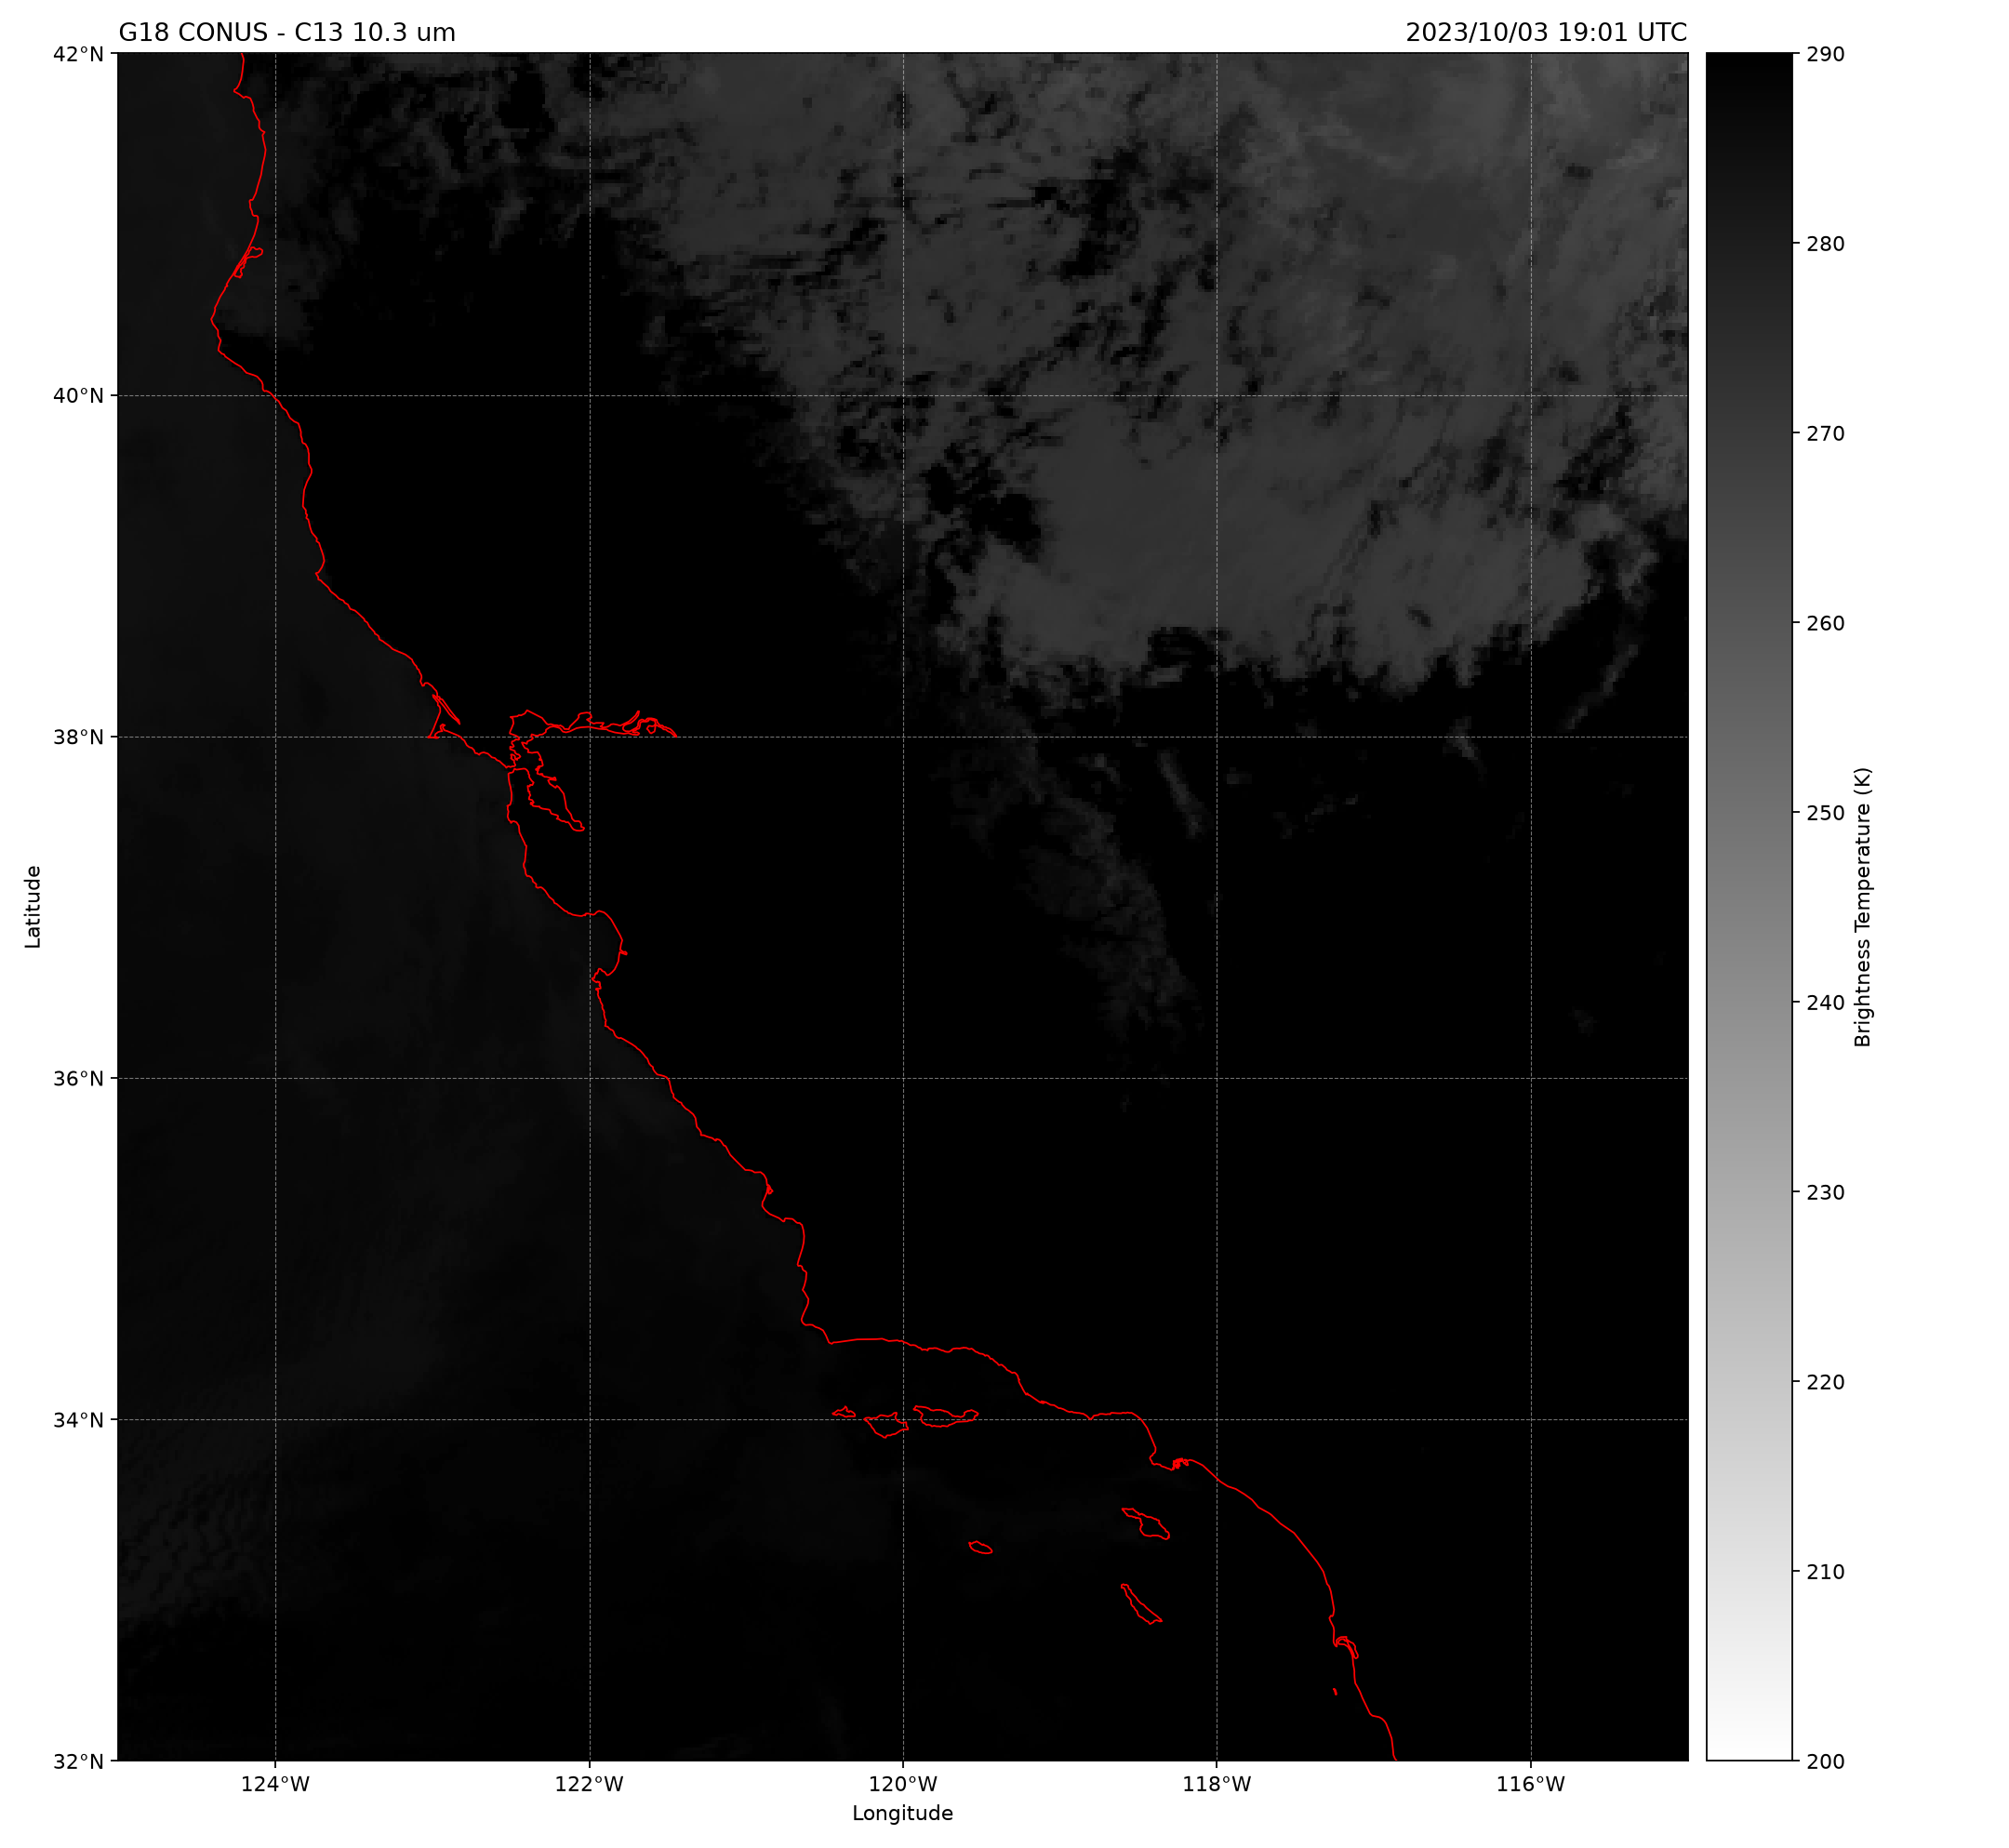

In [8]:
# ---------------------------------------------------------------
# 5. PLOT YOUR DOMAIN -- all of the drawing is here, change what you like
# ---------------------------------------------------------------
if DOMAIN is None:
    # No domain: the complete image, in the satellite's own geometry.
    native = scene[BAND].attrs["area"]
    step = 2 ** max(0, math.ceil(math.log2(max(native.width, native.height) / TARGET_PIXELS)))
    whole = scene.resample(native.aggregate(x=step, y=step), resampler="native")
    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(whole[BAND].values, origin="upper", cmap=CMAP, vmin=VMIN, vmax=VMAX)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title("G18 CONUS - " + TITLE + " (complete image)", loc="left")
    ax.set_title(f"{whole[BAND].attrs['start_time']:%Y/%m/%d %H:%M} UTC", loc="right")
    cb = fig.colorbar(im, ax=ax, pad=0.02, shrink=0.82)
    cb.set_label(COLOURBAR_LABEL)
    fig.tight_layout(); fig.savefig(OUT_DOMAIN, dpi=DPI); plt.close(fig)
    display(Image(filename=str(OUT_DOMAIN)))
else:
    area = create_area_def(
        "domain", {"proj": "longlat", "datum": "WGS84"},
        area_extent=DOMAIN, resolution=(RESOLUTION, RESOLUTION), units="degrees",
    )
    local = scene.resample(area)
    values = local[BAND].values
    west, south, east, north = DOMAIN

    fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_WIDTH * (north - south) / (east - west) * 0.92))

    im = ax.imshow(values, extent=(west, east, south, north), origin="upper",
                   aspect="auto", cmap=CMAP, vmin=VMIN, vmax=VMAX, zorder=0)

    ax.grid(color=GRID_COLOUR, alpha=GRID_ALPHA, ls=GRID_STYLE, lw=GRID_WIDTH, zorder=1)

    for line_x, line_y in coastlines(DOMAIN, COAST_RES):
        ax.plot(line_x, line_y, color=COAST_COLOUR, lw=COAST_WIDTH, zorder=4)

    if MARKER_LON is not None and west <= MARKER_LON <= east and south <= MARKER_LAT <= north:
        ax.plot(MARKER_LON, MARKER_LAT, "^", color=MARKER_COLOUR, ms=MARKER_SIZE, zorder=6)

    ax.set_xlim(west, east); ax.set_ylim(south, north)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lon_label))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lat_label))
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title("G18 CONUS - " + TITLE, loc="left")
    ax.set_title(f"{local[BAND].attrs['start_time']:%Y/%m/%d %H:%M} UTC", loc="right")

    cb = fig.colorbar(im, ax=ax, pad=0.01)
    cb.set_label(COLOURBAR_LABEL)

    fig.tight_layout()
    fig.savefig(OUT_DOMAIN, dpi=DPI)
    plt.close(fig)
    display(Image(filename=str(OUT_DOMAIN)))
